# Time Series Forecasting: Advanced Techniques

This notebook covers advanced time series forecasting methods including ARIMA modeling, Box-Jenkins methodology, multiple forecasting approaches, and validation techniques.


📺 **Video Lecture:** [https://youtu.be/ziH9_Ahgq4s](https://youtu.be/ziH9_Ahgq4s)

In [2]:
# Prerequisites and imports
# pip install statsmodels  # Uncomment to install

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Try importing statsmodels - ARIMA will fail gracefully if not installed
try:
    from statsmodels.tsa.arima.model import ARIMA
    from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
    from statsmodels.tsa.stattools import adfuller
    STATSMODELS_AVAILABLE = True
except ImportError:
    print("statsmodels not available. Install with: pip install statsmodels")
    STATSMODELS_AVAILABLE = False

np.random.seed(42)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)

## 1. Generate Synthetic Time Series Data

We create synthetic data with trend, seasonality, and noise to demonstrate forecasting techniques.


In [3]:
# Generate synthetic time series with trend, seasonality, and noise
n_periods = 200
t = np.arange(n_periods)

# Components
trend = 0.5 * t  # Linear trend
seasonality = 10 * np.sin(2 * np.pi * t / 12)  # Seasonal pattern (12 periods)
noise = np.random.normal(0, 2, n_periods)  # Gaussian noise

# Combine components
ts_data = trend + seasonality + noise + 50

# Create DataFrame
df = pd.DataFrame({
    'time': pd.date_range('2020-01-01', periods=n_periods, freq='M'),
    'value': ts_data
})
df.set_index('time', inplace=True)

# Split into train and test
train_size = int(0.8 * len(df))
train, test = df[:train_size], df[train_size:]

print(f"Dataset shape: {df.shape}")
print(f"Train: {train.shape}, Test: {test.shape}")
print(f"\nFirst few values:")
print(df.head())

Dataset shape: (200, 1)
Train: (160, 1), Test: (40, 1)

First few values:
                value
time                 
2020-01-31  50.993428
2020-02-29  55.223471
2020-03-31  60.955631
2020-04-30  64.546060
2020-05-31  60.191947


## 2. Visualize the Time Series

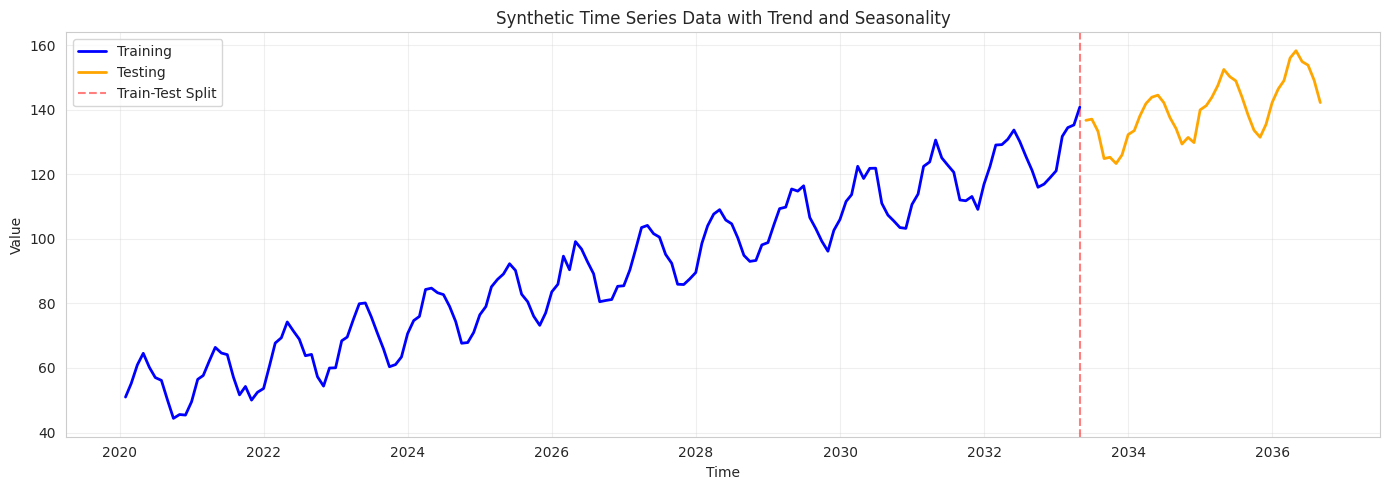

In [4]:
# Plot the complete time series
plt.figure(figsize=(14, 5))
plt.plot(train.index, train['value'], label='Training', color='blue', linewidth=2)
plt.plot(test.index, test['value'], label='Testing', color='orange', linewidth=2)
plt.axvline(x=train.index[-1], color='red', linestyle='--', alpha=0.5, label='Train-Test Split')
plt.title('Synthetic Time Series Data with Trend and Seasonality')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Stationarity Testing (ADF Test)

In [5]:
if STATSMODELS_AVAILABLE:
    # Augmented Dickey-Fuller test for stationarity
    result = adfuller(train['value'].dropna())
    print("Augmented Dickey-Fuller Test Results:")
    print(f"ADF Statistic: {result[0]:.6f}")
    print(f"p-value: {result[1]:.6f}")
    print(f"Critical Values:")
    for key, value in result[4].items():
        print(f"  {key}: {value:.3f}")
    
    if result[1] > 0.05:
        print("\nConclusion: Time series is NOT stationary (p > 0.05)")
    else:
        print("\nConclusion: Time series is stationary (p <= 0.05)")
else:
    print("statsmodels not available for ADF test")

Augmented Dickey-Fuller Test Results:
ADF Statistic: 0.480082
p-value: 0.984255
Critical Values:
  1%: -3.476
  5%: -2.882
  10%: -2.577

Conclusion: Time series is NOT stationary (p > 0.05)


## 4. Differencing to Achieve Stationarity

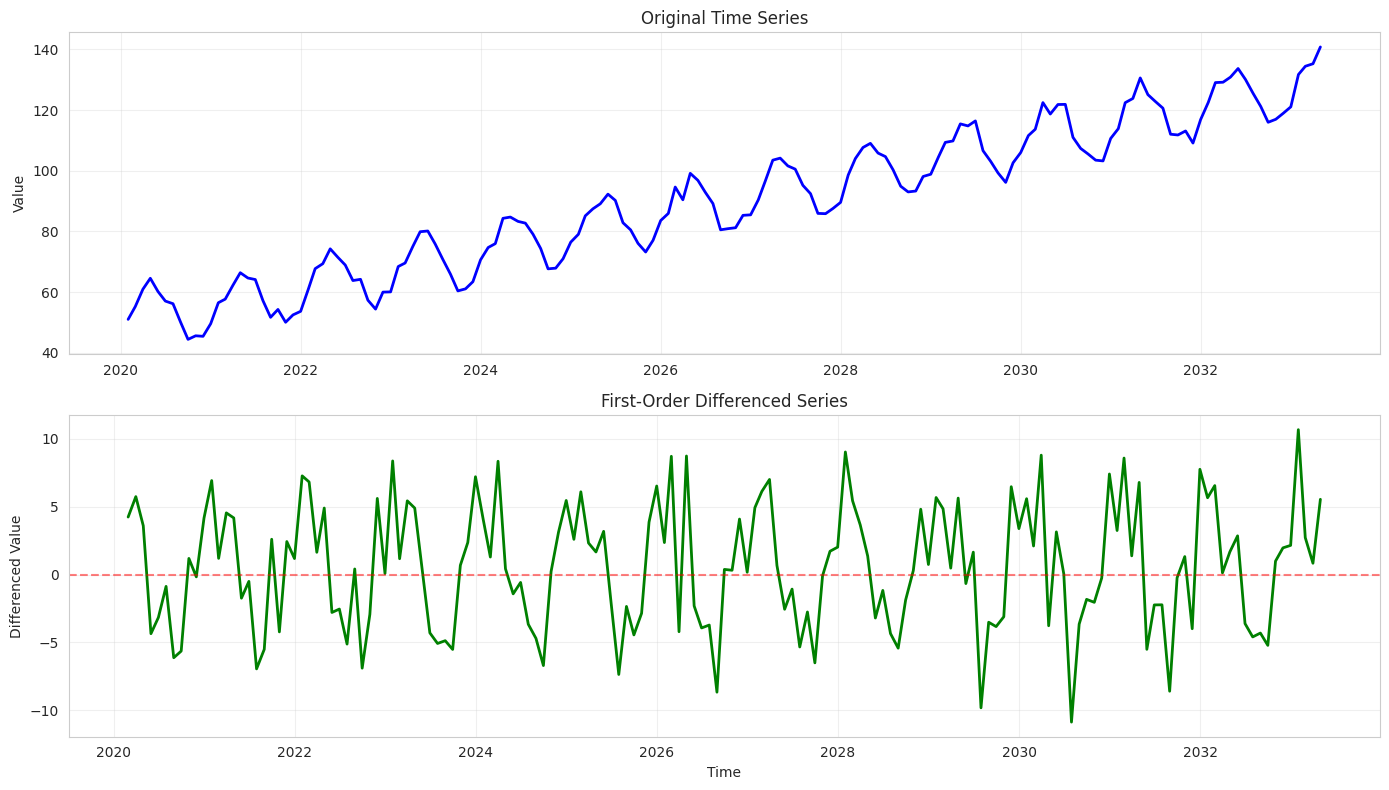


ADF test on differenced series:
ADF Statistic: -8.572666
p-value: 0.000000
Stationary: True


In [6]:
# First-order differencing
diff_series = train['value'].diff().dropna()

# Visualize original vs differenced
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Original
axes[0].plot(train.index, train['value'], color='blue', linewidth=2)
axes[0].set_title('Original Time Series')
axes[0].set_ylabel('Value')
axes[0].grid(True, alpha=0.3)

# Differenced
axes[1].plot(train.index[1:], diff_series.values, color='green', linewidth=2)
axes[1].set_title('First-Order Differenced Series')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Differenced Value')
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

if STATSMODELS_AVAILABLE:
    # Test differenced series for stationarity
    result_diff = adfuller(diff_series)
    print(f"\nADF test on differenced series:")
    print(f"ADF Statistic: {result_diff[0]:.6f}")
    print(f"p-value: {result_diff[1]:.6f}")
    print(f"Stationary: {result_diff[1] <= 0.05}")

## 5. ACF and PACF Analysis (Box-Jenkins Methodology)

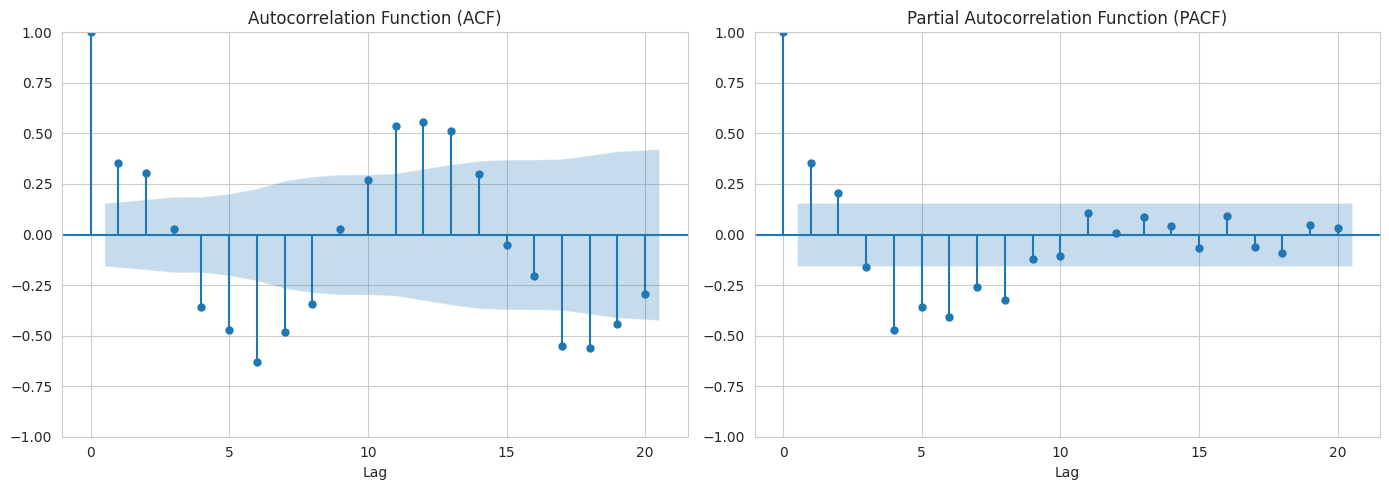


Box-Jenkins Methodology:
- ACF: Helps identify MA (Moving Average) order
- PACF: Helps identify AR (Autoregressive) order
- Look for significant spikes beyond the blue confidence bands


In [7]:
if STATSMODELS_AVAILABLE:
    # Plot ACF and PACF for differenced series
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # ACF plot
    plot_acf(diff_series, lags=20, ax=axes[0])
    axes[0].set_title('Autocorrelation Function (ACF)')
    axes[0].set_xlabel('Lag')
    
    # PACF plot
    plot_pacf(diff_series, lags=20, ax=axes[1], method='ywm')
    axes[1].set_title('Partial Autocorrelation Function (PACF)')
    axes[1].set_xlabel('Lag')
    
    plt.tight_layout()
    plt.show()
    
    print("\nBox-Jenkins Methodology:")
    print("- ACF: Helps identify MA (Moving Average) order")
    print("- PACF: Helps identify AR (Autoregressive) order")
    print("- Look for significant spikes beyond the blue confidence bands")
else:
    print("statsmodels not available for ACF/PACF plots")

## 6. Implementing Forecast Evaluation Metrics

In [8]:
def calculate_metrics(y_true, y_pred):
    """
    Calculate common time series evaluation metrics.
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    # Mean Absolute Scaled Error (MASE)
    n = len(y_true)
    d = np.abs(np.diff(y_true)).sum() / (n - 1)
    errors = np.abs(y_true - y_pred)
    mase = errors.mean() / d if d != 0 else np.inf
    
    return {
        'MAE': mae,
        'RMSE': rmse,
        'MAPE': mape,
        'MASE': mase
    }

print("Forecast Evaluation Metrics:")
print("- MAE (Mean Absolute Error): Average absolute errors")
print("- RMSE (Root Mean Squared Error): Penalizes large errors")
print("- MAPE (Mean Absolute Percentage Error): Percentage error")
print("- MASE (Mean Absolute Scaled Error): Scale-independent")

Forecast Evaluation Metrics:
- MAE (Mean Absolute Error): Average absolute errors
- RMSE (Root Mean Squared Error): Penalizes large errors
- MAPE (Mean Absolute Percentage Error): Percentage error
- MASE (Mean Absolute Scaled Error): Scale-independent


## 7. Naive Forecasting Method

Naive Forecast Results:
MAE: 7.5256
RMSE: 9.0370
MAPE: 0.0543
MASE: 2.0758


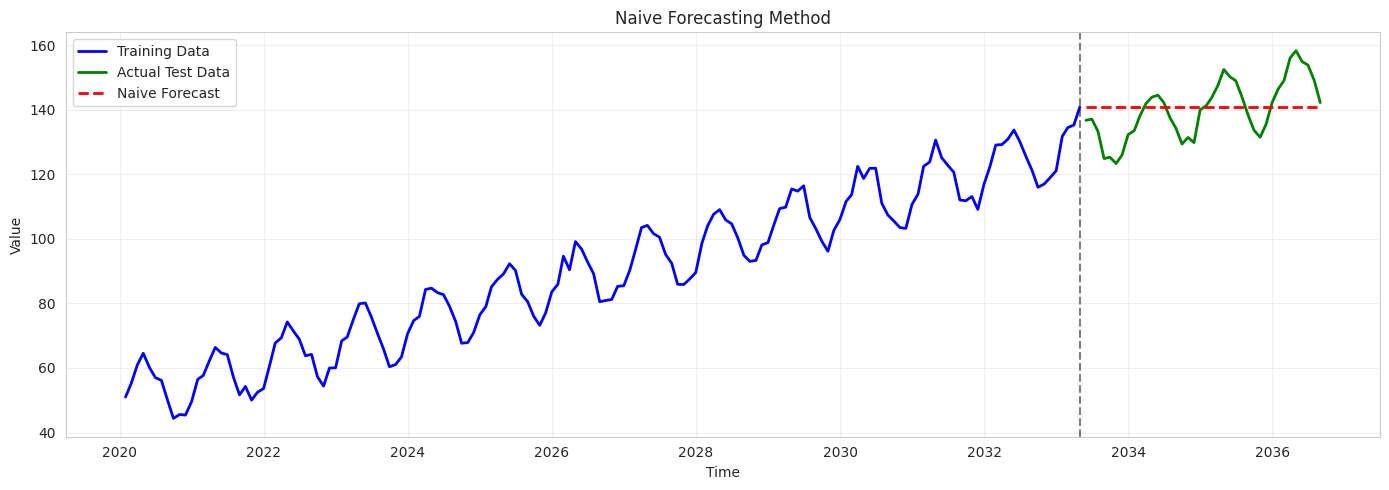

In [9]:
# Naive forecast: use last value from training set
naive_forecast = np.full(len(test), train['value'].iloc[-1])

naive_metrics = calculate_metrics(test['value'].values, naive_forecast)

print("Naive Forecast Results:")
for metric, value in naive_metrics.items():
    print(f"{metric}: {value:.4f}")

# Visualize naive forecast
plt.figure(figsize=(14, 5))
plt.plot(train.index, train['value'], label='Training Data', color='blue', linewidth=2)
plt.plot(test.index, test['value'], label='Actual Test Data', color='green', linewidth=2)
plt.plot(test.index, naive_forecast, label='Naive Forecast', color='red', linestyle='--', linewidth=2)
plt.axvline(x=train.index[-1], color='black', linestyle='--', alpha=0.5)
plt.title('Naive Forecasting Method')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Exponential Smoothing

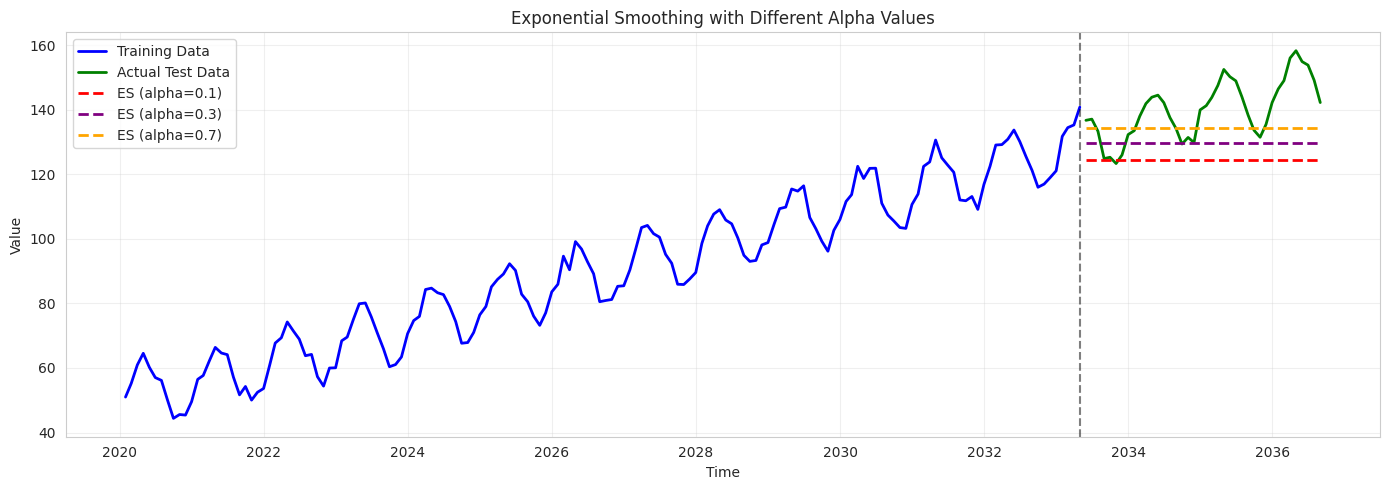

Exponential Smoothing Results (RMSE):
alpha=0.1: RMSE=18.1226
alpha=0.3: RMSE=13.8717
alpha=0.7: RMSE=10.6204


In [10]:
def exponential_smoothing(series, alpha=0.3, forecast_steps=1):
    """
    Simple exponential smoothing forecast.
    alpha: smoothing parameter (0-1)
    """
    result = [series.iloc[0]]  # Start with first value
    
    # Fit on training data
    for i in range(1, len(series)):
        result.append(alpha * series.iloc[i-1] + (1 - alpha) * result[-1])
    
    # Forecast
    forecasts = [result[-1]] * forecast_steps
    return np.array(result), np.array(forecasts)

# Apply exponential smoothing with different alpha values
alphas = [0.1, 0.3, 0.7]
es_forecasts = {}
es_metrics = {}

for alpha in alphas:
    _, forecast = exponential_smoothing(train['value'], alpha=alpha, forecast_steps=len(test))
    es_forecasts[alpha] = forecast
    es_metrics[alpha] = calculate_metrics(test['value'].values, forecast)

# Visualize
plt.figure(figsize=(14, 5))
plt.plot(train.index, train['value'], label='Training Data', color='blue', linewidth=2)
plt.plot(test.index, test['value'], label='Actual Test Data', color='green', linewidth=2)

colors = ['red', 'purple', 'orange']
for alpha, color in zip(alphas, colors):
    plt.plot(test.index, es_forecasts[alpha], label=f'ES (alpha={alpha})', color=color, linestyle='--', linewidth=2)

plt.axvline(x=train.index[-1], color='black', linestyle='--', alpha=0.5)
plt.title('Exponential Smoothing with Different Alpha Values')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Exponential Smoothing Results (RMSE):")
for alpha in alphas:
    print(f"alpha={alpha}: RMSE={es_metrics[alpha]['RMSE']:.4f}")

## 9. ARIMA Model (if statsmodels available)

In [11]:
if STATSMODELS_AVAILABLE:
    # Fit ARIMA model
    # ARIMA(p, d, q) where:
    # p: AR order (from PACF)
    # d: differencing order
    # q: MA order (from ACF)
    
    arima_order = (1, 1, 1)  # Simple example
    
    model = ARIMA(train['value'], order=arima_order)
    arima_result = model.fit()
    
    print(f"ARIMA{arima_order} Model Summary:")
    print(arima_result.summary())
else:
    print("statsmodels not installed. Install with: pip install statsmodels")
    arima_result = None

ARIMA(1, 1, 1) Model Summary:
                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  160
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -454.238
Date:                Fri, 24 Apr 2026   AIC                            914.475
Time:                        17:25:08   BIC                            923.682
Sample:                    01-31-2020   HQIC                           918.214
                         - 04-30-2033                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5562      0.179      3.108      0.002       0.206       0.907
ma.L1         -0.2064      0.219     -0.944      0.345      -0.635       0.222
sigma2        17.7209 

/sessions/nice-zen-knuth/.local/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/sessions/nice-zen-knuth/.local/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/sessions/nice-zen-knuth/.local/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


## 10. ARIMA Forecasting and Evaluation

ARIMA(1, 1, 1) Forecast Metrics:
MAE: 8.5531
RMSE: 10.3504
MAPE: 0.0632
MASE: 2.3592


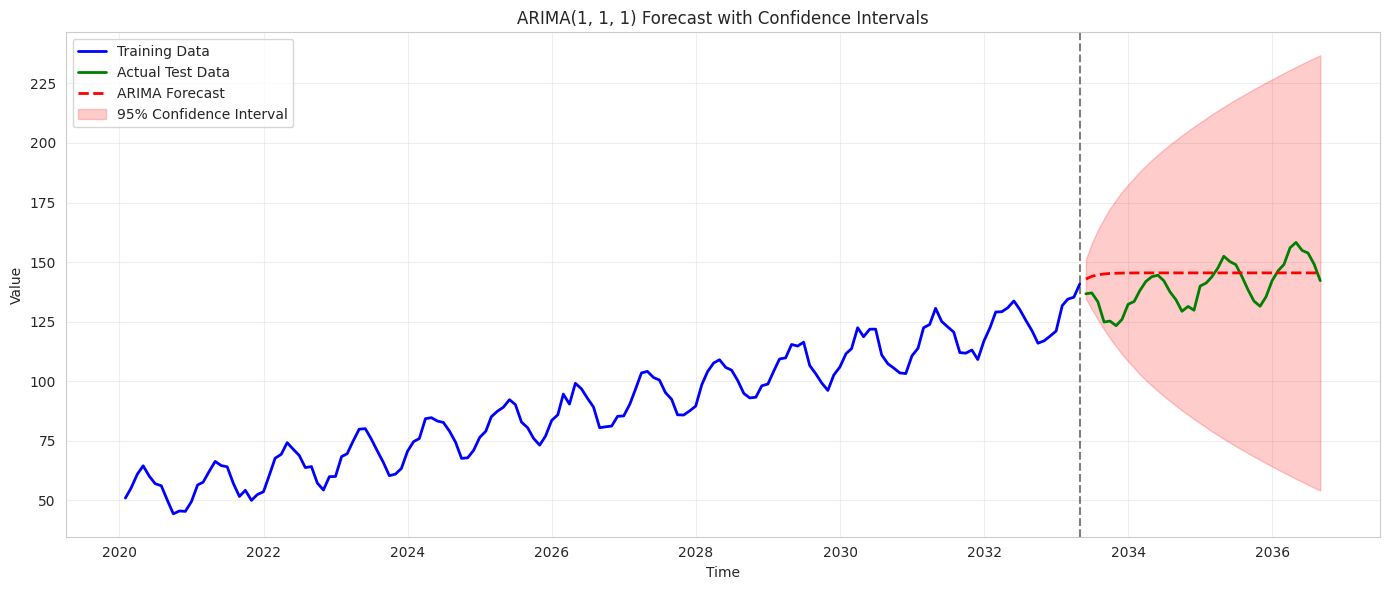

In [12]:
if STATSMODELS_AVAILABLE and arima_result is not None:
    # Generate forecast with confidence intervals
    forecast_steps = len(test)
    forecast_result = arima_result.get_forecast(steps=forecast_steps)
    forecast_df = forecast_result.conf_int(alpha=0.05)
    forecast_values = forecast_result.predicted_mean.values
    
    # Calculate metrics
    arima_metrics = calculate_metrics(test['value'].values, forecast_values)
    
    arima_order = (1, 1, 1)
    print(f"ARIMA{arima_order} Forecast Metrics:")
    for metric, value in arima_metrics.items():
        print(f"{metric}: {value:.4f}")
    
    # Visualize forecast with confidence intervals
    plt.figure(figsize=(14, 6))
    plt.plot(train.index, train['value'], label='Training Data', color='blue', linewidth=2)
    plt.plot(test.index, test['value'], label='Actual Test Data', color='green', linewidth=2)
    plt.plot(test.index, forecast_values, label='ARIMA Forecast', color='red', linestyle='--', linewidth=2)
    
    # Add confidence interval
    plt.fill_between(test.index,
                     forecast_df.iloc[:, 0],
                     forecast_df.iloc[:, 1],
                     color='red', alpha=0.2, label='95% Confidence Interval')
    
    plt.axvline(x=train.index[-1], color='black', linestyle='--', alpha=0.5)
    plt.title(f'ARIMA{arima_order} Forecast with Confidence Intervals')
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("ARIMA forecasting requires statsmodels")
    arima_metrics = None

## 11. Multi-Step Ahead Forecasting

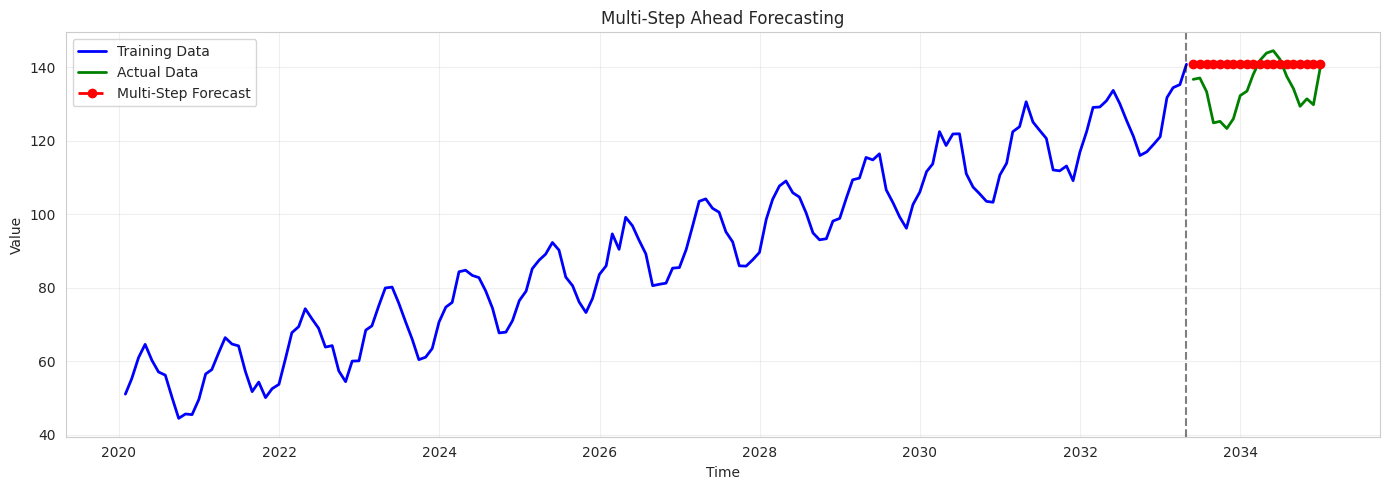

In [13]:
def multi_step_forecast_exponential_smoothing(series, alpha=0.3, steps_ahead=10):
    """
    Generate multi-step ahead forecasts using exponential smoothing.
    Returns list of forecasts at each step.
    """
    forecasts = []
    current_level = series.iloc[-1]
    
    for step in range(steps_ahead):
        # For simple exponential smoothing, forecast is constant (no trend)
        forecast = current_level
        forecasts.append(forecast)
    
    return np.array(forecasts)

# Generate multi-step forecasts
steps_ahead = 20
multi_step_forecast = multi_step_forecast_exponential_smoothing(train['value'], alpha=0.3, steps_ahead=steps_ahead)

# Create future index
future_index = pd.date_range(start=train.index[-1], periods=steps_ahead+1, freq='M')[1:]

# Visualize
plt.figure(figsize=(14, 5))
plt.plot(train.index, train['value'], label='Training Data', color='blue', linewidth=2)
plt.plot(test.index[:steps_ahead], test['value'].iloc[:steps_ahead], label='Actual Data', color='green', linewidth=2)
plt.plot(future_index, multi_step_forecast, label='Multi-Step Forecast', color='red', linestyle='--', linewidth=2, marker='o')
plt.axvline(x=train.index[-1], color='black', linestyle='--', alpha=0.5)
plt.title('Multi-Step Ahead Forecasting')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 12. Walk-Forward Validation (Backtesting)

In [14]:
def walk_forward_validation(data, initial_train_size, test_size, method='exponential_smoothing'):
    """
    Perform walk-forward validation for time series forecasting.
    This simulates realistic out-of-sample testing.
    """
    all_predictions = []
    all_actuals = []
    
    # Perform walk-forward iterations
    for i in range(len(data) - initial_train_size - test_size):
        # Training window
        train_window = data.iloc[i:i + initial_train_size]
        # Test window
        test_window = data.iloc[i + initial_train_size:i + initial_train_size + test_size]
        
        # Fit model and forecast
        if method == 'exponential_smoothing':
            _, predictions = exponential_smoothing(train_window, alpha=0.3, forecast_steps=test_size)
        elif method == 'naive':
            predictions = np.full(test_size, train_window.iloc[-1])
        
        all_predictions.extend(predictions[:len(test_window)])
        all_actuals.extend(test_window.values)
    
    return np.array(all_actuals), np.array(all_predictions)

# Perform walk-forward validation
initial_train_size = 120
test_size = 5

actuals_es, predictions_es = walk_forward_validation(
    df['value'], 
    initial_train_size=initial_train_size,
    test_size=test_size,
    method='exponential_smoothing'
)

actuals_naive, predictions_naive = walk_forward_validation(
    df['value'],
    initial_train_size=initial_train_size,
    test_size=test_size,
    method='naive'
)

# Calculate metrics
metrics_es = calculate_metrics(actuals_es, predictions_es)
metrics_naive = calculate_metrics(actuals_naive, predictions_naive)

print("Walk-Forward Validation Results:")
print("\nExponential Smoothing:")
for metric, value in metrics_es.items():
    print(f"  {metric}: {value:.4f}")

print("\nNaive Forecast:")
for metric, value in metrics_naive.items():
    print(f"  {metric}: {value:.4f}")

Walk-Forward Validation Results:

Exponential Smoothing:
  MAE: 9.6568
  RMSE: 10.9450
  MAPE: 0.0744
  MASE: 2.0218

Naive Forecast:
  MAE: 8.5178
  RMSE: 10.2213
  MAPE: 0.0661
  MASE: 1.7834


## 13. Comparison of Forecasting Methods


Forecast Methods Comparison:
                           Method       MAE      RMSE     MAPE
                            Naive  7.525560  9.036967 0.054279
Exponential Smoothing (alpha=0.3) 11.496074 13.871671 0.079052
Exponential Smoothing (alpha=0.7)  8.612914 10.620427 0.059709
                   ARIMA(1, 1, 1)  8.553116 10.350447 0.063232


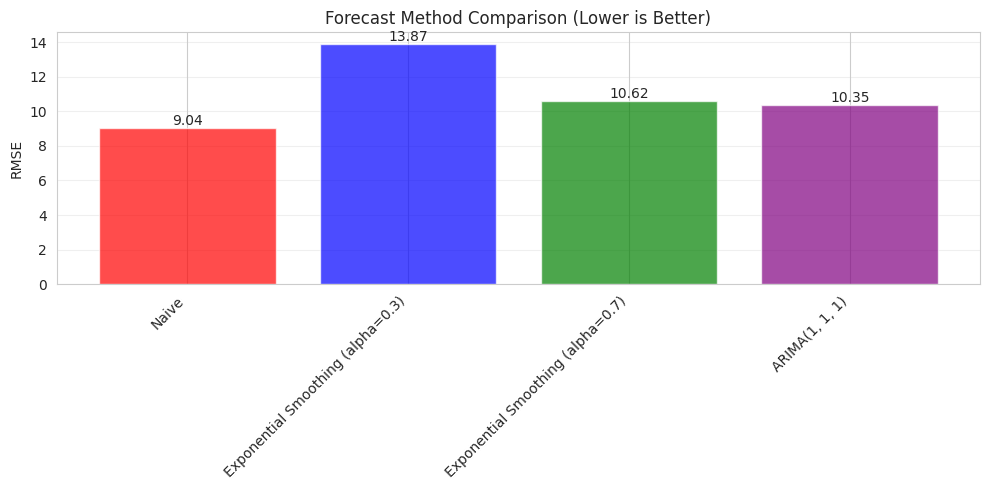

In [15]:
# Create comparison table
comparison_data = {
    'Method': ['Naive', 'Exponential Smoothing (alpha=0.3)', 'Exponential Smoothing (alpha=0.7)'],
    'MAE': [naive_metrics['MAE'], es_metrics[0.3]['MAE'], es_metrics[0.7]['MAE']],
    'RMSE': [naive_metrics['RMSE'], es_metrics[0.3]['RMSE'], es_metrics[0.7]['RMSE']],
    'MAPE': [naive_metrics['MAPE'], es_metrics[0.3]['MAPE'], es_metrics[0.7]['MAPE']],
}

if STATSMODELS_AVAILABLE and arima_metrics is not None:
    arima_order = (1, 1, 1)
    comparison_data['Method'].append(f'ARIMA{arima_order}')
    comparison_data['MAE'].append(arima_metrics['MAE'])
    comparison_data['RMSE'].append(arima_metrics['RMSE'])
    comparison_data['MAPE'].append(arima_metrics['MAPE'])

comparison_df = pd.DataFrame(comparison_data)
print("\nForecast Methods Comparison:")
print(comparison_df.to_string(index=False))

# Visualize RMSE comparison
plt.figure(figsize=(10, 5))
methods = comparison_df['Method'].values
rmse_values = comparison_df['RMSE'].values
colors_bar = ['red', 'blue', 'green', 'purple'][:len(methods)]
bars = plt.bar(range(len(methods)), rmse_values, color=colors_bar, alpha=0.7)
plt.xticks(range(len(methods)), methods, rotation=45, ha='right')
plt.ylabel('RMSE')
plt.title('Forecast Method Comparison (Lower is Better)')
plt.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}',
             ha='center', va='bottom')

plt.tight_layout()
plt.show()

## 14. Residual Analysis

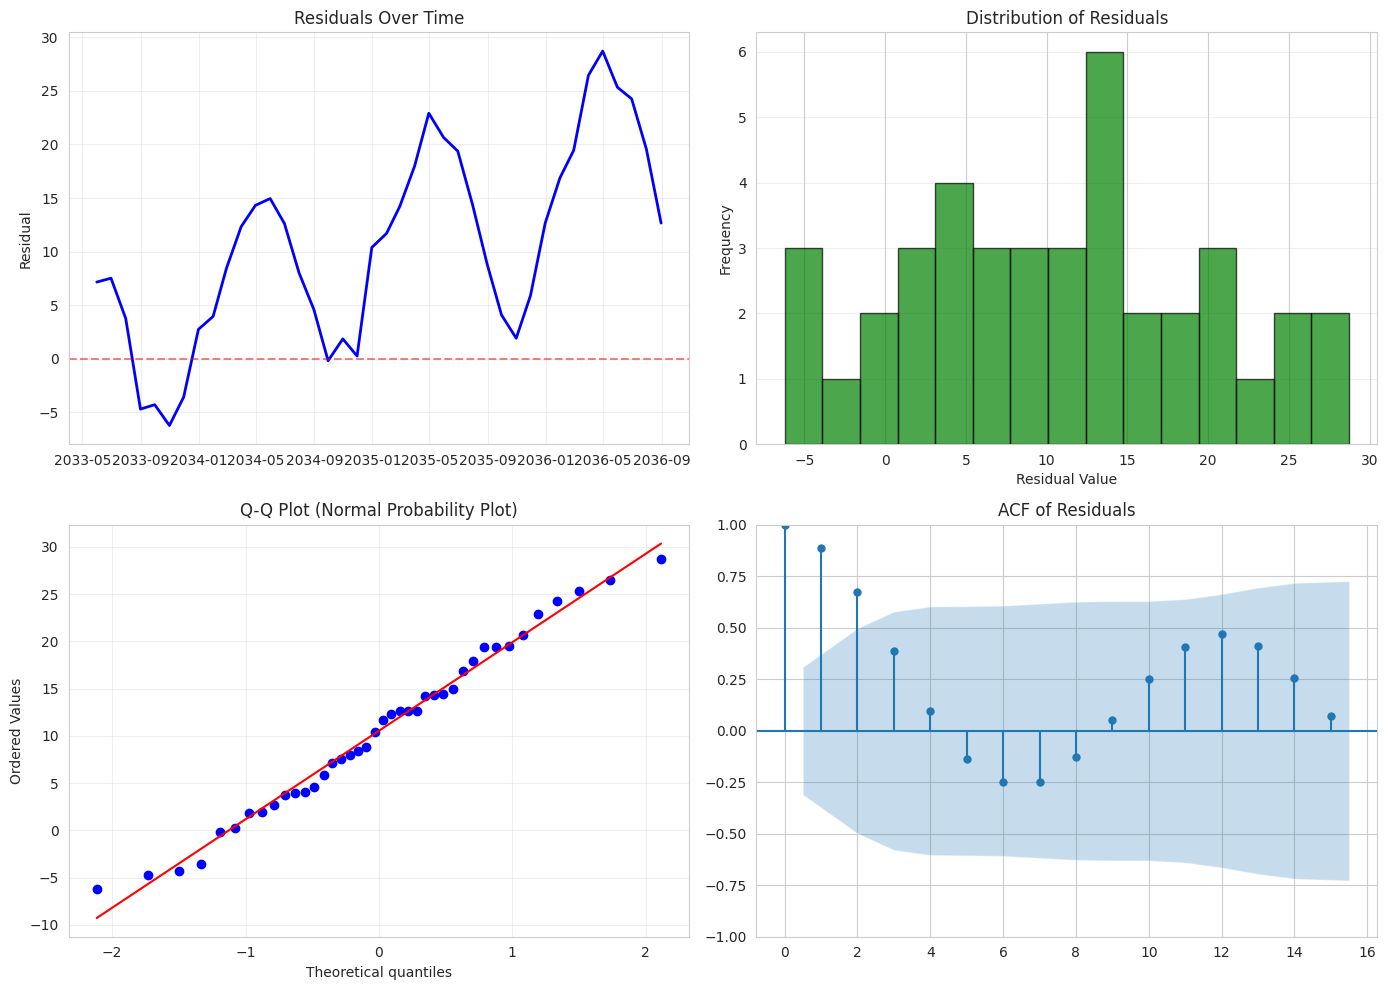


Residual Statistics:
Mean: 10.548249
Std Dev: 9.008757
Skewness: 0.072534
Kurtosis: -0.786463

Ljung-Box Test (Testing for Autocorrelation):
      lb_stat     lb_pvalue
5   62.281641  4.100330e-12
10  73.033308  1.147146e-11


In [16]:
# Calculate residuals for exponential smoothing
es_forecast = es_forecasts[0.3]
residuals = test['value'].values - es_forecast

# Create residual analysis plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuals over time
axes[0, 0].plot(test.index, residuals, color='blue', linewidth=2)
axes[0, 0].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[0, 0].set_title('Residuals Over Time')
axes[0, 0].set_ylabel('Residual')
axes[0, 0].grid(True, alpha=0.3)

# 2. Histogram of residuals
axes[0, 1].hist(residuals, bins=15, color='green', alpha=0.7, edgecolor='black')
axes[0, 1].set_title('Distribution of Residuals')
axes[0, 1].set_xlabel('Residual Value')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Q-Q plot (Normal Probability Plot)
stats.probplot(residuals, dist='norm', plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot (Normal Probability Plot)')
axes[1, 0].grid(True, alpha=0.3)

# 4. ACF of residuals
if STATSMODELS_AVAILABLE:
    from statsmodels.graphics.tsaplots import plot_acf
    plot_acf(residuals, lags=15, ax=axes[1, 1])
    axes[1, 1].set_title('ACF of Residuals')
else:
    # Manual ACF calculation if statsmodels not available
    lags = 15
    acf_values = [1.0]  # ACF at lag 0 is always 1
    for lag in range(1, lags+1):
        c0 = np.sum((residuals - residuals.mean())**2) / len(residuals)
        c_lag = np.sum((residuals[:-lag] - residuals.mean()) * (residuals[lag:] - residuals.mean())) / len(residuals)
        acf_values.append(c_lag / c0)
    
    axes[1, 1].bar(range(len(acf_values)), acf_values, color='blue', alpha=0.7)
    axes[1, 1].axhline(y=0, color='black')
    axes[1, 1].axhline(y=1.96/np.sqrt(len(residuals)), color='red', linestyle='--')
    axes[1, 1].axhline(y=-1.96/np.sqrt(len(residuals)), color='red', linestyle='--')
    axes[1, 1].set_title('ACF of Residuals')
    axes[1, 1].set_ylabel('ACF')
    axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Residual statistics
print("\nResidual Statistics:")
print(f"Mean: {residuals.mean():.6f}")
print(f"Std Dev: {residuals.std():.6f}")
print(f"Skewness: {stats.skew(residuals):.6f}")
print(f"Kurtosis: {stats.kurtosis(residuals):.6f}")

# Ljung-Box test for autocorrelation (if statsmodels available)
if STATSMODELS_AVAILABLE:
    from statsmodels.stats.diagnostic import acorr_ljungbox
    lb_test = acorr_ljungbox(residuals, lags=[5, 10], return_df=True)
    print("\nLjung-Box Test (Testing for Autocorrelation):")
    print(lb_test)

## 15. Summary and Key Takeaways

In [17]:
summary = """
ADVANCED TIME SERIES FORECASTING - KEY CONCEPTS:

1. STATIONARITY: Required for ARIMA models
   - Test with ADF (Augmented Dickey-Fuller)
   - Achieve through differencing (d parameter)

2. BOX-JENKINS METHODOLOGY:
   - ACF: Identifies MA (q) order
   - PACF: Identifies AR (p) order
   - Iterative process of model selection

3. ARIMA(p,d,q) PARAMETERS:
   - p: Autoregressive order
   - d: Differencing order
   - q: Moving Average order

4. EVALUATION METRICS:
   - MAE: Mean absolute error (interpretable units)
   - RMSE: Penalizes large errors
   - MAPE: Percentage error
   - MASE: Scale-independent comparison

5. FORECASTING METHODS:
   - Naive: Baseline method
   - Exponential Smoothing: Weighted average of past values
   - ARIMA: Combines AR, I(differencing), MA components

6. VALIDATION TECHNIQUES:
   - Walk-forward validation: Realistic backtesting
   - Confidence intervals: Uncertainty quantification
   - Residual analysis: Model diagnostics

7. RESIDUAL CHECKS:
   - Mean should be ~0 (unbiased)
   - Should be normally distributed
   - Should have no autocorrelation (Ljung-Box test)
   - No patterns or trends
"""

print(summary)


ADVANCED TIME SERIES FORECASTING - KEY CONCEPTS:

1. STATIONARITY: Required for ARIMA models
   - Test with ADF (Augmented Dickey-Fuller)
   - Achieve through differencing (d parameter)

2. BOX-JENKINS METHODOLOGY:
   - ACF: Identifies MA (q) order
   - PACF: Identifies AR (p) order
   - Iterative process of model selection

3. ARIMA(p,d,q) PARAMETERS:
   - p: Autoregressive order
   - d: Differencing order
   - q: Moving Average order

4. EVALUATION METRICS:
   - MAE: Mean absolute error (interpretable units)
   - RMSE: Penalizes large errors
   - MAPE: Percentage error
   - MASE: Scale-independent comparison

5. FORECASTING METHODS:
   - Naive: Baseline method
   - Exponential Smoothing: Weighted average of past values
   - ARIMA: Combines AR, I(differencing), MA components

6. VALIDATION TECHNIQUES:
   - Walk-forward validation: Realistic backtesting
   - Confidence intervals: Uncertainty quantification
   - Residual analysis: Model diagnostics

7. RESIDUAL CHECKS:
   - Mean should

---

<small><em>© 2026 AI Nirvana · More Info: https://medium.com/@snigam/a-simple-structured-way-to-prepare-for-ai-ml-interviews-68b2e5830195 · Disclaimer: Provided as is. No liability assumed.</em></small>